In [193]:
import numpy as np
import os
import glob
from datetime import datetime
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from statsmodels.stats.multitest import multipletests


# import sys
# sys.path.insert(0, '..')
from probe import plot_heatmap

In [287]:
# --- settings ---
dynamic = '0_forward'  # 0_backward, 0_forward
variable = 'action'  # belief, action
belief = 'oracle'  # multinomial, oracle, protagonist

num_test = 0  # n stories excluded from probing
val_size = 0.5  # train-val split ratio
group_stories = True

m1_name = 'Qwen3-8B'
m2_name = 'Qwen3-8B-MARSHAL'

### val accuracy

In [130]:
# d_m1_path = f'data/results/probe/{m1_name}/{dynamic}_{variable}_{belief}_val_acc.npy'
d_m1_path = glob.glob(f'data/results/probe/{m1_name}/total{200-num_test}_val{val_size}_group{group_stories}*/{dynamic}_{variable}_{belief}_val_acc.npy')[0]
d_m1 = np.load(d_m1_path)
print(d_m1.shape)

# d_m2_path = f'data/results/probe/{m2_name}/{dynamic}_{variable}_{belief}_val_acc.npy'
d_m2_path = glob.glob(f'data/results/probe/{m2_name}/total{200-num_test}_val{val_size}_group{group_stories}*/{dynamic}_{variable}_{belief}_val_acc.npy')[0]
d_m2 = np.load(d_m2_path)
print(d_m2.shape)

(36, 32)
(36, 32)


In [131]:
print(f"max: {np.max(d_m2 - d_m1)}")
print(f"min: {np.min(d_m2 - d_m1)}")

max: 0.05249999999999999
min: -0.039999999999999925


In [132]:
save_path = f'data/results/probe/{m2_name}_{m1_name}/total{200-num_test}_val{val_size}_group{group_stories}'
if not os.path.exists(save_path): os.makedirs(save_path)
plot_heatmap(
    d_m2 - d_m1, 
    "Probe Val Acc Diff.", 
    save_path=f"{save_path}/{dynamic}_{variable}_{belief}_val_acc",
    vmin=-0.2, vmax=0.2,
    cmap='coolwarm'
)

### hit rate stats

In [288]:
d_m1_path = glob.glob(f'data/results/probe/{m1_name}/total{200-num_test}_val{val_size}_group{group_stories}*/{dynamic}_{variable}_{belief}_val_hits.npy')[0]
d_m1 = np.load(d_m1_path)  # (36, 32, 800)

d_m2_path = glob.glob(f'data/results/probe/{m2_name}/total{200-num_test}_val{val_size}_group{group_stories}*/{dynamic}_{variable}_{belief}_val_hits.npy')[0]
d_m2 = np.load(d_m2_path)

aggregated val accuracy sanity check using hit counts

In [289]:
n_entries = np.sum(~np.isnan(d_m1[0, 0, :]))
d1_accu = np.nansum(d_m1, axis=2)/(n_entries)
print(d1_accu)
# sns.heatmap(d1_accu)

[[0.7    0.7025 0.6975 ... 0.705  0.6975 0.7175]
 [0.7525 0.7625 0.775  ... 0.805  0.7875 0.775 ]
 [0.8475 0.8625 0.8225 ... 0.8475 0.8175 0.8525]
 ...
 [0.6975 0.6575 0.6725 ... 0.64   0.6475 0.68  ]
 [0.71   0.69   0.705  ... 0.7675 0.795  0.705 ]
 [0.755  0.7675 0.71   ... 0.7975 0.73   0.765 ]]


In [290]:
d2_accu = np.nansum(d_m2, axis=2)/n_entries
print(d2_accu)
# sns.heatmap(d2_accu)

[[0.6925 0.6975 0.71   ... 0.7025 0.7075 0.72  ]
 [0.7525 0.7675 0.775  ... 0.8025 0.785  0.7675]
 [0.8475 0.8575 0.82   ... 0.85   0.8175 0.8575]
 ...
 [0.6525 0.655  0.6225 ... 0.6425 0.635  0.685 ]
 [0.7275 0.69   0.7025 ... 0.7675 0.7575 0.6875]
 [0.7375 0.7575 0.7025 ... 0.7675 0.7475 0.76  ]]


In [291]:
def mean_every_k(arr: np.ndarray, k: int) -> np.ndarray:
    a, b, c = arr.shape
    return arr.reshape(a, b, c // k, k).mean(axis=-1)

In [292]:
# compute per-story accuracy
d_m1_mean = mean_every_k(d_m1, 4)
d_m2_mean = mean_every_k(d_m2, 4)

In [293]:
# two-tailed paired t-test across stories
t_stat, p_value = stats.ttest_rel(d_m1_mean, d_m2_mean, axis=2, nan_policy='omit')
p_value

array([[0.49404974, 0.56631551, 0.02458952, ..., 0.79771959, 0.04493473,
        0.65699051],
       [1.        , 0.5297892 , 1.        , ..., 0.65699051, 0.65699051,
        0.08324863],
       [1.        , 0.15833991, 0.31974847, ..., 0.31974847, 1.        ,
        0.41695715],
       ...,
       [0.01182384, 0.89353558, 0.02836093, ..., 0.87372097, 0.59862241,
        0.74738659],
       [0.33881459, 1.        , 0.89353558, ..., 1.        , 0.04639768,
        0.32947396],
       [0.31974847, 0.50772156, 0.68794776, ..., 0.12188845, 0.43946342,
        0.79077964]])

In [294]:
(p_value < 0.05).sum()

np.int64(60)

In [295]:
def plot_heatmap_highlight(
    d_m1_accu,
    d_m2_accu,
    p_value,
    save_path=None,
    figsize=(10, 8),
    xlabel="Head",
    ylabel="Layer",
    title="Diff: Encoding Strengths of Head Outputs",
    sig_thresh=0.05,
):

    diff = d_m2_accu - d_m1_accu

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        diff,
        cmap="coolwarm",
        vmin=-0.1,
        vmax=0.1,
        square=True,
        ax=ax,
        cbar_kws={"label": "Encoding Strengths Diff"},
    )

    # Highlight significant cells
    sig = p_value < sig_thresh
    for i, j in zip(*np.where(sig)):
        ax.add_patch(
            plt.Rectangle(
                (j, i),
                1,
                1,
                fill=False,
                edgecolor="black",
                lw=0.5,
            )
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, ax

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Diff: Encoding Strengths of Head Outputs \n0_forward_action_oracle'}, xlabel='Head', ylabel='Layer'>)

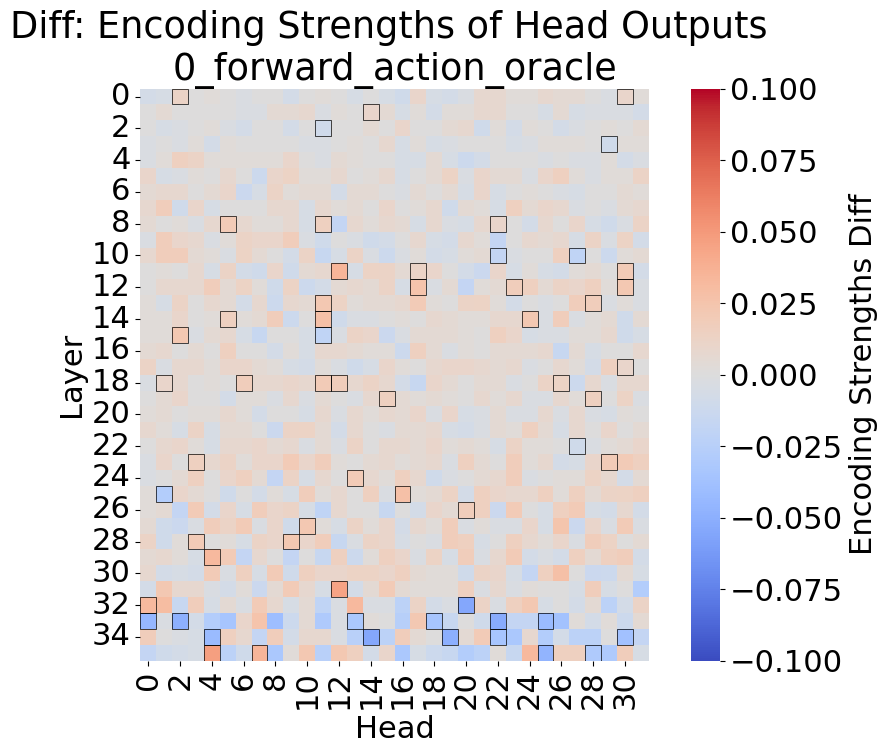

In [296]:
save_path = f'data/results/probe/{m2_name}_{m1_name}/total{200-num_test}_val{val_size}_group{group_stories}'
plot_heatmap_highlight(
    d1_accu,
    d2_accu,
    p_value,
    save_path=f"{save_path}/{dynamic}_{variable}_{belief}_val_acc_sig",
    figsize=(10, 8),
    xlabel="Head",
    ylabel="Layer",
    title=f"Diff: Encoding Strengths of Head Outputs \n{dynamic}_{variable}_{belief}",
    sig_thresh=0.05,
)

In [226]:
def multipletests_ignore_nan(pvals, alpha=0.05, method='fdr_bh'):
    pvals = np.asarray(pvals, dtype=float)
    mask = ~np.isnan(pvals)
    
    reject = np.full(pvals.shape, np.nan)
    pvals_corrected = np.full(pvals.shape, np.nan)
    
    if mask.any():
        reject[mask], pvals_corrected[mask], _, _ = multipletests(
            pvals[mask], alpha=alpha, method=method
        )
    
    return reject, pvals_corrected

In [227]:
p_value_flat = p_value.flatten()
rejected, pvals_corrected = multipletests_ignore_nan(p_value_flat, alpha=0.05, method='fdr_bh')

# Reshape back to original shape
rejected = rejected.reshape(p_value.shape)
pvals_corrected = pvals_corrected.reshape(p_value.shape)

(pvals_corrected < 0.05).sum()

np.int64(0)

In [228]:
pvals_corrected

array([[       nan, 0.86933874,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [0.61139177, 0.92730542, 0.94928133, ..., 1.        , 0.9417533 ,
        0.42345544],
       ...,
       [0.93589088, 1.        , 0.69175141, ..., 0.90118053, 0.92630639,
        0.92630639],
       [1.        , 0.92730542, 0.92630639, ..., 0.94928133, 0.94928133,
        0.92730542],
       [0.89203903, 0.94928133, 0.90118053, ..., 0.91752214, 0.93589088,
        0.92630639]])